In [28]:
import os

import geopandas as gpd
import contextily as ctx
from owslib.wms import WebMapService
import matplotlib.pyplot as plt

from detect_wildlife_crossings.wms.helpers import get_crop_bboxes


In [5]:
CRS = "EPSG:3035"  # ETRS89 / LAEA Europe, for import and WMS request
OUTPUT_DIR = "../data/documentation/"
PIXEL_RESOLUTION_M = 2  # 2 meters per pixel
BUFFER_SIZE = 640

In [7]:
WMS_URL = "https://image.discomap.eea.europa.eu/arcgis/services/GioLand/VHR_2021_LAEA/ImageServer/WMSServer/?request=GetCapabilities&service=WMS"
wms = WebMapService(
    WMS_URL,
    version="1.3.0",
)
layer_name = list(wms.contents)[0]
print(layer_name)

VHR_2021_LAEA


In [37]:
x = 3457203.26
y = 2423293.88

df = gpd.GeoDataFrame(
    data=[[x, y]],
    columns=["x", "y"],
    crs=CRS,
    geometry=gpd.points_from_xy([x], [y]),
)
bbox = get_crop_bboxes(df, 640)[0]
bbox

(3456563.26, 2422653.88, 3457843.26, 2423933.88)

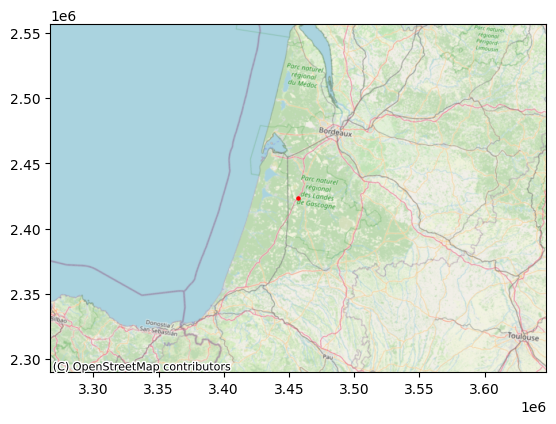

In [38]:
df.plot(marker="o", color="red", markersize=5)
ctx.add_basemap(ax=plt.gca(), crs=CRS, source=ctx.providers.OpenStreetMap.Mapnik)

In [39]:
# for every point create a square around it and request a WMS crop centered on the point
img_format = "image/jpeg"
img_size = (
    int(BUFFER_SIZE * 2 / PIXEL_RESOLUTION_M),
    int(BUFFER_SIZE * 2 / PIXEL_RESOLUTION_M),
)  # width, height in pixels

# Request WMS image
img = wms.getmap(
    layers=[layer_name],
    srs=CRS,
    bbox=bbox,
    size=img_size,
    format=img_format,
    transparent=True,
)

with open(os.path.join(OUTPUT_DIR, "compare_wms_object_detector.jpg"), "wb") as f:
    f.write(img.read())